# Tuner Gap Sweep Analysis\n\nKey thesis figures: disk intracavity flux vs tuner gap distance.\n- **Overlay plot**: all 14 gap spectra in one figure\n- **Waterfall plot**: stacked disk flux peaks showing resonance shift\n- **Tuning curve**: resonance frequency vs gap

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.signal import find_peaks
import os, glob

# Publication style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 11,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "mathtext.fontset": "cm",
})

COL_WIDTH = 3.4   # single journal column (inches)
DBL_WIDTH = 7.0   # double journal column (inches)
c0 = 299792458    # m/s

# Custom colormap: dark purple → light blue
cmap_custom = LinearSegmentedColormap.from_list(
    "purple_blue",
    [mcolors.to_rgb("#400F77"), mcolors.to_rgb("#A1C9E9")],
    N=256,
)

# Frequency ↔ wavelength helpers
def thz_to_nm(f): return c0 / (f * 1e12) * 1e9
def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12

SAVE = True

In [7]:
# ============================================================
# Load data from all tuner gap folders
# ============================================================
DATA_DIR = "thesis_data/20251211_1742_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.1"

fig_dir = os.path.join(DATA_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)

# Find all tunergap folders
gap_folders = sorted(glob.glob(os.path.join(DATA_DIR, "tunergap_*um")))
print(f"Found {len(gap_folders)} tuner gap folders")

# Load each gap's data
gaps_nm = []       # gap in nm
freqs = None       # shared frequency axis (THz)
spectra_disk = []  # normalized |flux_disk / norm_flux|

for folder in gap_folders:
    # Parse gap value from folder name
    basename = os.path.basename(folder)
    gap_um = float(basename.replace("tunergap_", "").replace("um", ""))
    gap_nm_val = gap_um * 1000

    f = np.load(os.path.join(folder, "freqs_thz.npy"))
    flux_disk = np.load(os.path.join(folder, "flux_disk.npy"))
    norm_flux = np.load(os.path.join(folder, "norm_flux.npy"))

    # Normalize
    norm = np.where(np.abs(norm_flux) > 1e-20, norm_flux, 1e-20)
    spectrum = np.abs(flux_disk / norm)

    gaps_nm.append(gap_nm_val)
    spectra_disk.append(spectrum)
    if freqs is None:
        freqs = f

gaps_nm = np.array(gaps_nm)
spectra_disk = np.array(spectra_disk)  # shape: (n_gaps, n_freqs)

print(f"Gaps (nm): {gaps_nm}")
print(f"Freq range: {freqs[0]:.1f} - {freqs[-1]:.1f} THz")
print(f"Spectra shape: {spectra_disk.shape}")

Found 14 tuner gap folders
Gaps (nm): [ 4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 20. 30. 40. 50.]
Freq range: 308.0 - 328.0 THz
Spectra shape: (14, 30000)


## Plot 1: All spectra overlay

/tmp/ipykernel_1447130/3028315095.py:45: RuntimeWarning: divide by zero encountered in divide
  def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12
/tmp/ipykernel_1447130/3028315095.py:45: RuntimeWarning: divide by zero encountered in divide
  def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12


Saved: thesis_data/20251211_1742_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.1/figures/disk_flux_overlay.pdf


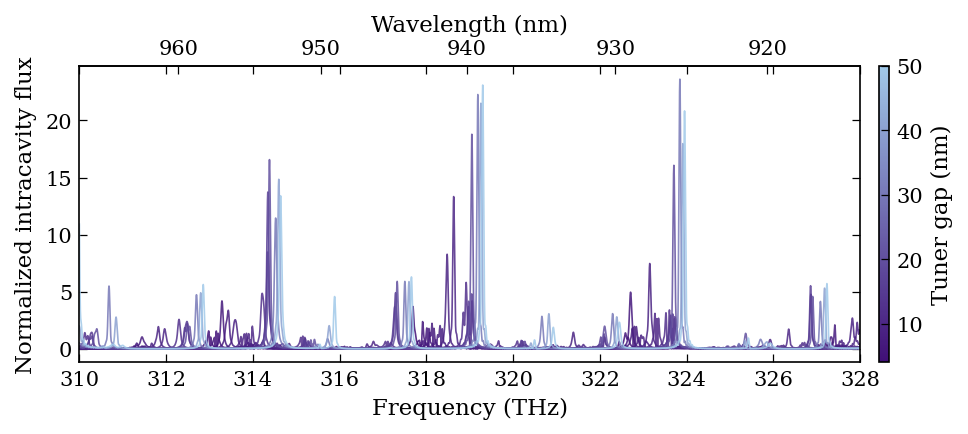

In [8]:
# ============================================================
# Plot 1: Overlay of all gap spectra (disk flux)
# ============================================================
# Zoom to the main resonance region
FREQ_MIN, FREQ_MAX = 310, 328  # THz

mask = (freqs >= FREQ_MIN) & (freqs <= FREQ_MAX)
f_zoom = freqs[mask]

norm_color = Normalize(vmin=gaps_nm.min(), vmax=gaps_nm.max())

fig, ax = plt.subplots(figsize=(DBL_WIDTH, 3.0))

for i, (gap, spec) in enumerate(zip(gaps_nm, spectra_disk)):
    color = cmap_custom(norm_color(gap))
    ax.plot(f_zoom, spec[mask], color=color, linewidth=0.8, alpha=0.85)

ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Normalized intracavity flux")
ax.set_xlim(FREQ_MIN, FREQ_MAX)

# Secondary wavelength axis
ax_top = ax.secondary_xaxis("top", functions=(thz_to_nm, nm_to_thz))
ax_top.set_xlabel("Wavelength (nm)")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm_color)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=30)
cbar.set_label("Tuner gap (nm)")

plt.tight_layout()

if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"disk_flux_overlay.{ext}"))
    print(f"Saved: {fig_dir}/disk_flux_overlay.pdf")

plt.show()

## Plot 2: Waterfall plot (stacked disk flux)

/tmp/ipykernel_1447130/3028315095.py:45: RuntimeWarning: divide by zero encountered in divide
  def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12
/tmp/ipykernel_1447130/3028315095.py:45: RuntimeWarning: divide by zero encountered in divide
  def nm_to_thz(l): return c0 / (l * 1e-9) * 1e-12


Saved: thesis_data/20251211_1742_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.1/figures/disk_flux_waterfall.pdf


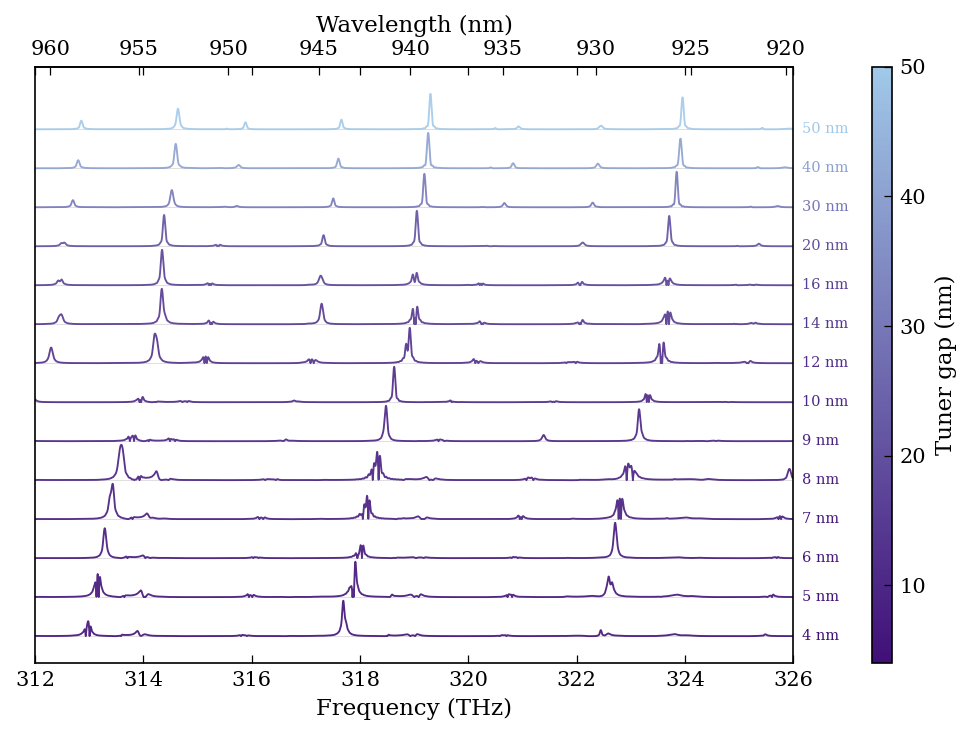

In [9]:
# ============================================================
# Plot 2: Waterfall plot — stacked disk flux spectra
# ============================================================
# Zoom to region around the strongest resonance for clarity
WF_FREQ_MIN, WF_FREQ_MAX = 312, 326  # THz
wf_mask = (freqs >= WF_FREQ_MIN) & (freqs <= WF_FREQ_MAX)
f_wf = freqs[wf_mask]

# Normalize each spectrum to [0, 1] so peaks have equal height
spectra_wf = spectra_disk[:, wf_mask].copy()
for i in range(len(spectra_wf)):
    smax = spectra_wf[i].max()
    if smax > 0:
        spectra_wf[i] /= smax

offset_step = 1.1  # slightly more than 1.0 so baselines don't overlap peaks

fig, ax = plt.subplots(figsize=(DBL_WIDTH, 5.0))

for i, (gap, spec) in enumerate(zip(gaps_nm, spectra_wf)):
    color = cmap_custom(norm_color(gap))
    offset = i * offset_step
    y = spec + offset

    # Baseline
    ax.axhline(y=offset, color="gray", linestyle="-", linewidth=0.3, alpha=0.4)
    # Spectrum
    ax.plot(f_wf, y, color=color, linewidth=0.9, alpha=0.9)
    # Gap label on right
    ax.text(WF_FREQ_MAX + 0.15, offset, f"{gap:.0f} nm",
            fontsize=7, color=color, va="center", ha="left")

ax.set_xlabel("Frequency (THz)")
ax.set_xlim(WF_FREQ_MIN, WF_FREQ_MAX)
ax.set_yticks([])

# Secondary wavelength axis
ax_top = ax.secondary_xaxis("top", functions=(thz_to_nm, nm_to_thz))
ax_top.set_xlabel("Wavelength (nm)")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm_color)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.08, aspect=30)
cbar.set_label("Tuner gap (nm)")

plt.tight_layout()

if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"disk_flux_waterfall.{ext}"))
    print(f"Saved: {fig_dir}/disk_flux_waterfall.pdf")

plt.show()

## Plot 3: Tuning curves — all tuner widths

  tw=50nm: 14 gaps, shift=-2.510 nm
  tw=90nm: 14 gaps, shift=-4.467 nm
  tw=100nm: 14 gaps, shift=-4.938 nm
  tw=80nm: 14 gaps, shift=-4.002 nm
  tw=70nm: 14 gaps, shift=-3.495 nm
  tw=60nm: 14 gaps, shift=-3.013 nm

Loaded 6 tuner widths: [50.0, 60.0, 70.0, 80.0, 90.0, 100.0] nm
Saved: thesis_data/20251211_1742_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.1/figures/tuning_curves_all_widths.pdf


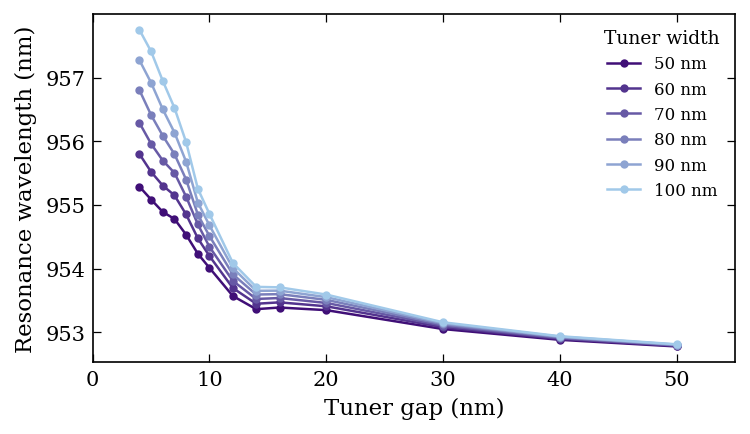

Saved: thesis_data/20251211_1742_norm_r3.5_g0.02_f318.000_res48_decay0.0005_tw0.1/figures/tuning_shift_all_widths.pdf


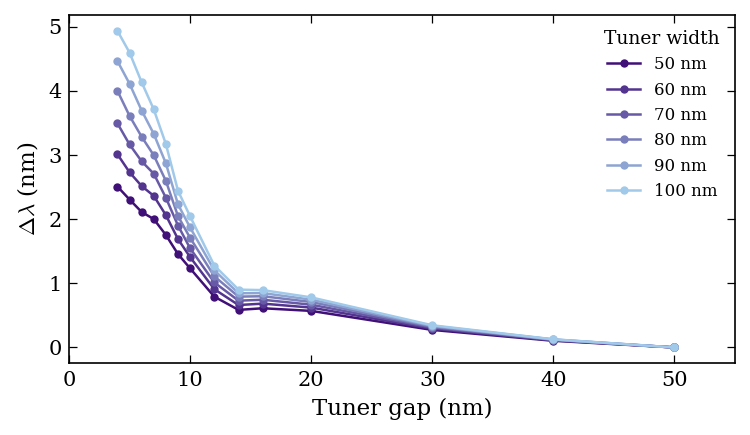

In [10]:
# ============================================================
# Plot 3: Tuning curves for ALL tuner widths
# ============================================================
# Load CSV fitting results from all 6 tuner width datasets

import re

sweep_dirs = sorted(glob.glob("thesis_data/*norm*"))
tuner_data = {}  # {tw_nm: {gaps_nm, freqs_thz, wavelengths_nm, ...}}

for d in sweep_dirs:
    # Parse tuner width from folder name
    tw_match = re.search(r"tw([\d.]+)", os.path.basename(d))
    if not tw_match:
        continue
    tw_um = float(tw_match.group(1))
    tw_nm = tw_um * 1000  # convert to nm

    # Find CSV
    csvs = glob.glob(os.path.join(d, "gap_sweep*.csv"))
    if not csvs:
        print(f"  tw={tw_nm:.0f}nm: no CSV found, skipping")
        continue

    csv_path = csvs[0]
    data = np.genfromtxt(csv_path, delimiter=",", names=True, comments="#")

    gaps = data["gap_um"] * 1000  # nm
    freqs_res = data["f_res_THz"]
    freqs_err = data["f_res_err_THz"]
    wavelengths = thz_to_nm(freqs_res)

    tuner_data[tw_nm] = {
        "gaps_nm": gaps,
        "freqs_thz": freqs_res,
        "freqs_err": freqs_err,
        "wavelengths_nm": wavelengths,
    }
    print(f"  tw={tw_nm:.0f}nm: {len(gaps)} gaps, "
          f"shift={wavelengths[-1] - wavelengths[0]:.3f} nm")

print(f"\nLoaded {len(tuner_data)} tuner widths: "
      f"{sorted(tuner_data.keys())} nm")

# --- Color scale by tuner width ---
tw_values = np.array(sorted(tuner_data.keys()))
norm_tw = Normalize(vmin=tw_values.min(), vmax=tw_values.max())

# --- Plot: wavelength vs gap for all tuner widths ---
fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.5, 3.0))

for tw_nm in tw_values:
    td = tuner_data[tw_nm]
    color = cmap_custom(norm_tw(tw_nm))
    ax.plot(td["gaps_nm"], td["wavelengths_nm"], "o-",
            color=color, markersize=3, linewidth=1.2,
            label=f"{tw_nm:.0f} nm")

ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel("Resonance wavelength (nm)")
ax.set_xlim(0, 55)
ax.legend(title="Tuner width", fontsize=8, title_fontsize=9)

plt.tight_layout()

if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"tuning_curves_all_widths.{ext}"))
    print(f"Saved: {fig_dir}/tuning_curves_all_widths.pdf")

plt.show()

# --- Plot: frequency shift (relative to largest gap) ---
fig, ax = plt.subplots(figsize=(COL_WIDTH * 1.5, 3.0))

for tw_nm in tw_values:
    td = tuner_data[tw_nm]
    # Shift relative to largest gap (weakest coupling)
    wl_shift = td["wavelengths_nm"] - td["wavelengths_nm"][-1]
    color = cmap_custom(norm_tw(tw_nm))
    ax.plot(td["gaps_nm"], wl_shift, "o-",
            color=color, markersize=3, linewidth=1.2,
            label=f"{tw_nm:.0f} nm")

ax.set_xlabel("Tuner gap (nm)")
ax.set_ylabel(r"$\Delta\lambda$ (nm)")
ax.set_xlim(0, 55)
ax.legend(title="Tuner width", fontsize=8, title_fontsize=9)

plt.tight_layout()

if SAVE:
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(fig_dir, f"tuning_shift_all_widths.{ext}"))
    print(f"Saved: {fig_dir}/tuning_shift_all_widths.pdf")

plt.show()